<a href="https://colab.research.google.com/github/AdithiPramod1/air-quality-prediction-/blob/main/airprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

module 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
file_path = '/content/drive/MyDrive/air_quality_data.csv'
df = pd.read_csv('/content/drive/MyDrive/air_quality_data.csv/city__day.csv')
df.head()


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df.set_index('Date')

In [ ]:
df.index.name = 'Datetime'

In [ ]:
df = df.sort_values(by='Datetime')

In [ ]:
df.fillna(df.select_dtypes(include='number').median(), inplace=True)

In [ ]:
df.isnull().sum()

,0
City,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0
O3,0


In [ ]:
df.fillna(df.select_dtypes(include='number').mean(), inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['DayOfWeek'] = df.index.dayofweek

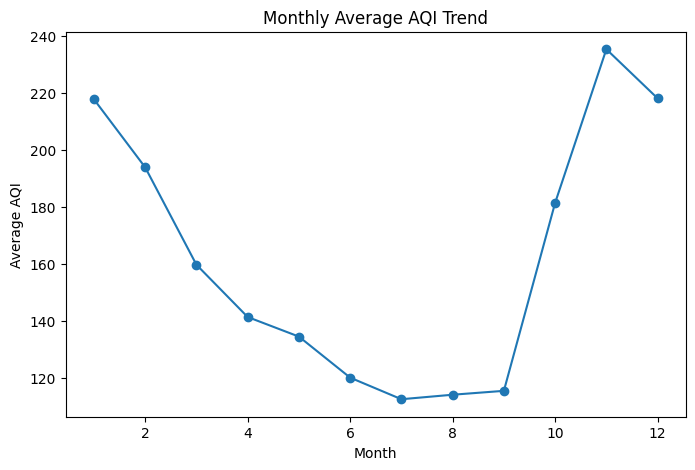

In [ ]:
monthly_avg = df.groupby('Month')['AQI'].mean()

plt.figure(figsize=(8,5))
monthly_avg.plot(marker='o')
plt.title("Monthly Average AQI Trend")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.show()

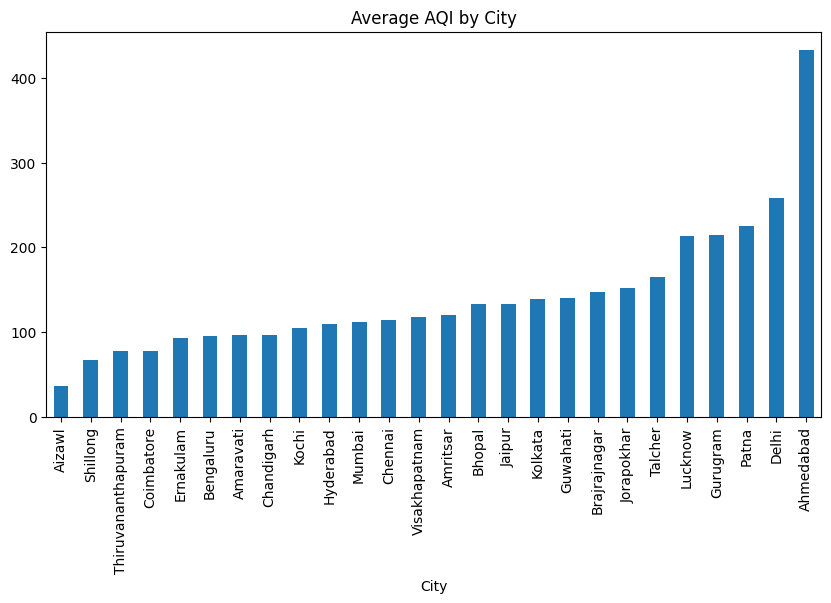

In [ ]:
city_avg = df.groupby('City')['AQI'].mean()

plt.figure(figsize=(10,5))
city_avg.sort_values().plot(kind='bar')
plt.title("Average AQI by City")
plt.show()

In [ ]:
df.to_csv("cleaned_air_quality.csv")

module 2

In [ ]:
df.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,Day,DayOfWeek
Datetime,,,,,,,,,,,,,,,,,,,
2015-01-01,Ahmedabad,48.57,95.68,0.92,18.22,17.15,15.85,0.92,27.64,133.36,0.00,0.02,0.00,118.0,NaN,2015,1,1,3
2015-01-01,Chennai,48.57,95.68,16.30,15.39,22.68,4.59,1.17,9.20,11.35,0.17,2.97,0.98,118.0,NaN,2015,1,1,3
2015-01-01,Delhi,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe,2015,1,1,3
2015-01-01,Lucknow,48.57,95.68,2.11,13.46,4.57,15.85,12.15,169.57,25.92,1.35,3.93,0.98,118.0,NaN,2015,1,1,3
2015-01-01,Mumbai,48.57,95.68,9.89,21.69,27.38,15.85,0.00,9.16,30.84,0.00,0.00,0.00,118.0,NaN,2015,1,1,3


In [ ]:
features = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Month','DayOfWeek']
X = df[features]
y = df['AQI']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 22.92841235672594
RMSE: 53.53365471337801
R2 Score: 0.8557436358705227


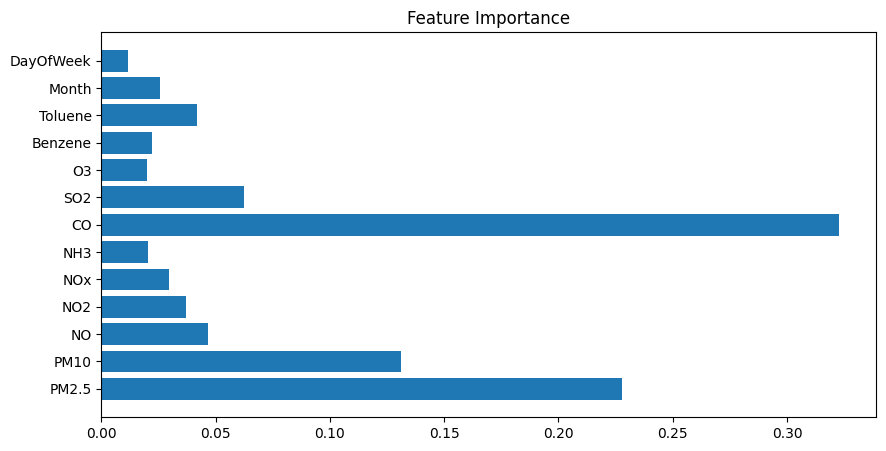

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure(figsize=(10,5))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()


In [ ]:
import joblib
joblib.dump(model, "aqi_model.pkl")

['aqi_model.pkl']

In [ ]:
from google.colab import files
files.download("aqi_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>